# Ex : 8
# Feed Forward Neural Network

---

### **Objective: Implementation of a Feed Forward Neural Network (FFNN)**

#### **Project Goal**
To implement a **Feed Forward Neural Network** for classification and understand its architecture, activation functions, backpropagation, and training dynamics.

#### **1. Dataset Selection**
*   **Dataset:** Heart Disease UCI Dataset (Kaggle).
*   **Samples:** 303 samples with 14 attributes.
*   **Classes:** Binary classification (0: No heart disease, 1: Heart disease present).
*   **Attributes:** Includes age, sex, chest pain type, blood pressure, cholesterol, etc.

#### **2. Network Architecture**
*   **Input Layer:** 13 neurons (matching the preprocessed features).
*   **Hidden Layer 1:** 16 neurons with **ReLU** activation.
*   **Hidden Layer 2:** 8 neurons with **ReLU** activation.
*   **Output Layer:** 1 neuron with **Sigmoid** activation (for binary probability).

#### **3. Hyperparameters**
*   **Learning Rate:** 0.001
*   **Optimizer:** Adam
*   **Epochs:** 150
*   **Batch Size:** 32
*   **Loss Function:** Binary Cross-Entropy
*   **Data Split:** 80% Training, 20% Testing

#### **4. Algorithm Overview**
A **Feed Forward Neural Network** is an artificial neural network where connections between nodes do not form a cycle. Information flows in one direction from input to output through hidden layers. Each neuron computes a weighted sum of inputs, applies an activation function, and passes the result forward. The network learns by comparing outputs with actual values using the delta rule, optimizing weights through **backpropagation** and gradient descent to improve accuracy.




-----
### **Step-by-Step Approach for Heart Disease Classification**

#### **Step 1: Import Required Libraries**
*   Import essential libraries: `NumPy`, `Pandas`, `TensorFlow/Keras`, `Matplotlib`, `Seaborn`.
*   Import `scikit-learn` modules for data preprocessing and evaluation metrics.

#### **Step 2: Load and Explore the Dataset**
*   Load the Heart Disease UCI dataset.
*   Perform initial exploration: check dataset shape, feature types, class distribution, and missing values.

#### **Step 3: Preprocess the Data**
*   Handle missing values and encode categorical variables if necessary.
*   Split the data into training (80%) and testing (20%) sets.
*   Apply `StandardScaler` to normalize input features for stable neural network training.

#### **Step 4: Build the Feed Forward Neural Network**
*   Construct a `Sequential` model:
    *   **Input Layer:** 13 neurons.
    *   **Hidden Layer 1:** 16 neurons with **ReLU** activation.
    *   **Hidden Layer 2:** 8 neurons with **ReLU** activation.
    *   **Output Layer:** 1 neuron with **Sigmoid** activation.

#### **Step 5: Compile and Train the Model**
*   **Compile:** Use the **Adam** optimizer (learning rate 0.001) and **Binary Cross-Entropy** loss.
*   **Train:** Run for 150 epochs with a batch size of 32.

#### **Step 6: Evaluate Model Performance**
*   Calculate test accuracy.
*   Generate a **Classification Report** (Precision, Recall, F1-Score).
*   Plot a **Confusion Matrix** to analyze prediction errors.

#### **Step 7: Visualize Training History**
*   Plot **Accuracy** and **Loss** curves for both training and validation sets.
*   Analyze the curves to check for convergence or overfitting.



---

## Step 1: Import Required Libraries

In [15]:
# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
#from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### Explanation:
- **numpy, pandas**: For data manipulation and analysis
- **matplotlib, seaborn**: For data visualization
- **sklearn**: Provides SVM implementation and evaluation metrics
- **PCA**: For dimensionality reduction (helps in visualization)
- **GridSearchCV**: For hyperparameter tuning

## Step 2: Load and Explore the Dataset

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 
           'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns, na_values='?')

print("\n" + "="*60)
print("HEART DISEASE DATASET")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()


HEART DISEASE DATASET
Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
print(f"\nClass distribution:")
print(df['target'].value_counts())


Class distribution:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [4]:
# Dataset information
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
print("\nDataset Info:")
df.info()

print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)
print("\nStatistical Summary:")
df.describe()


DATASET INFORMATION

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

STATISTICAL SUMMARY

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [5]:
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES CHECK")
print("="*50)
print(df.isnull().sum())


MISSING VALUES CHECK
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


----
## Step 3: Data Preprocessing 

In [6]:
# Step 3: Data Preprocessing

# Convert to binary classification (0: no disease, 1: disease present)
df['target'] = (df['target'] > 0).astype(int)
print(f"\nBinary class distribution:\n{df['target'].value_counts()}")

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']




Binary class distribution:
target
0    164
1    139
Name: count, dtype: int64


In [7]:
#  Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")




Training set size: 242 samples
Testing set size: 61 samples


In [8]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Features scaled successfully!")

✅ Features scaled successfully!


### Why Scaling is Critical for SVM:
- SVM tries to maximize the margin between classes
- Features with larger scales would dominate the distance calculation
- Standard scaling ensures all features contribute equally
- Without scaling, the SVM hyperplane would be biased

----
## Step 4 : Build the Feed Forward Neural Network

In [9]:
print("\n" + "="*60)
print("BUILDING FEED FORWARD NEURAL NETWORK")
print("="*60)

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu', name='hidden_layer_1'),
    layers.Dense(8, activation='relu', name='hidden_layer_2'),
    layers.Dense(1, activation='sigmoid', name='output_layer')
])

model.summary()


BUILDING FEED FORWARD NEURAL NETWORK


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

----
## Step 5: Compile and Train the Model

In [10]:
print("\n" + "="*60)
print("TRAINING THE MODEL")
print("="*60)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("✅ Model training completed!")


TRAINING THE MODEL
Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6676 - loss: 0.6235 - val_accuracy: 0.5510 - val_loss: 0.6929
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4201 - loss: 0.6936 - val_accuracy: 0.5510 - val_loss: 0.6928
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4188 - loss: 0.6938 - val_accuracy: 0.5510 - val_loss: 0.6928
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4432 - loss: 0.6935 - val_accuracy: 0.5510 - val_loss: 0.6930
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4257 - loss: 0.6933 - val_accuracy: 0.5510 - val_loss: 0.6931
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4443 - loss: 0.6931 - val_accuracy: 0.4490 - val_loss: 0.6934
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5716 - loss: 0.6928 - val_accuracy: 0.4490 - val_loss: 0.6935
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5741 - loss: 0.6926 - val_accuracy

---
# Step 6: Evaluate Model Performance

In [11]:
# Step 6: Evaluate Model Performance
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Make predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


MODEL EVALUATION
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Test Accuracy: 0.5410

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.54      1.00      0.70        33
     Disease       0.00      0.00      0.00        28

    accuracy                           0.54        61
   macro avg       0.27      0.50      0.35        61
weighted avg       0.29      0.54      0.38        61



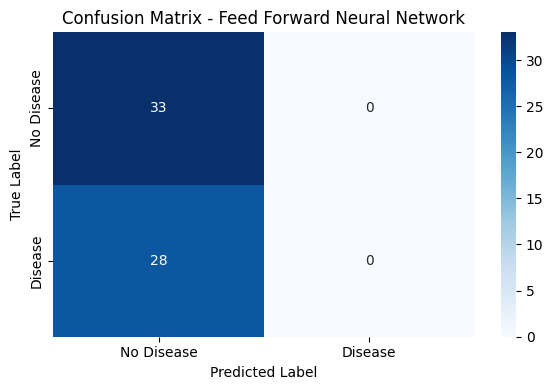

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Feed Forward Neural Network')
plt.tight_layout()
plt.show()

-----
## Step 7 : Visualization Training History


TRAINING HISTORY


Text(0.5, 1.0, 'Model Accuracy')

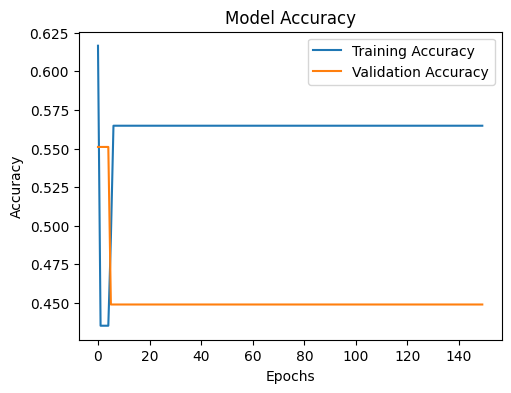

In [13]:
print("\n" + "="*60)
print("TRAINING HISTORY")
print("="*60)

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

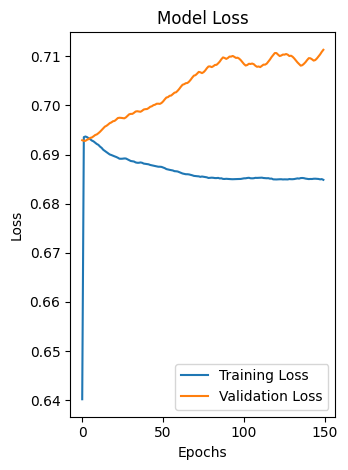


✅ Feed Forward Neural Network implementation completed successfully!


In [14]:
# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.tight_layout()
plt.show()

print("\n✅ Feed Forward Neural Network implementation completed successfully!")